<a href="https://colab.research.google.com/github/Azira18/audio-restoration-musicgen/blob/main/03_Stems_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import and Utilities

In [ ]:
# =================================================================
#                 GOOGLE COLAB ENVIRONMENT SETUP
# =================================================================
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_PATH = '/content/drive/MyDrive/audio-restoration-musicgen'
os.chdir(PROJECT_PATH)

!pip install -q mir_eval librosa soundfile

# ==========================
#          IMPORT
# ==========================
import torch
import librosa
import numpy as np
import soundfile as sf
import matplotlib.pyplot as plt
from IPython.display import Audio, display
import librosa.display
import mir_eval

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.8/102.8 kB 3.2 MB/s eta 0:00:00


# Visual Analysis
This section is dedicated to a visual comparison between the original and clean stems. In particular, we will analyze:
- the waveforms compared;
- the waveform of the removed noise (original - denoised);
- the spectrograms compared.

What we would like to see is a cleaner waveform and a less noisy spectrogram.

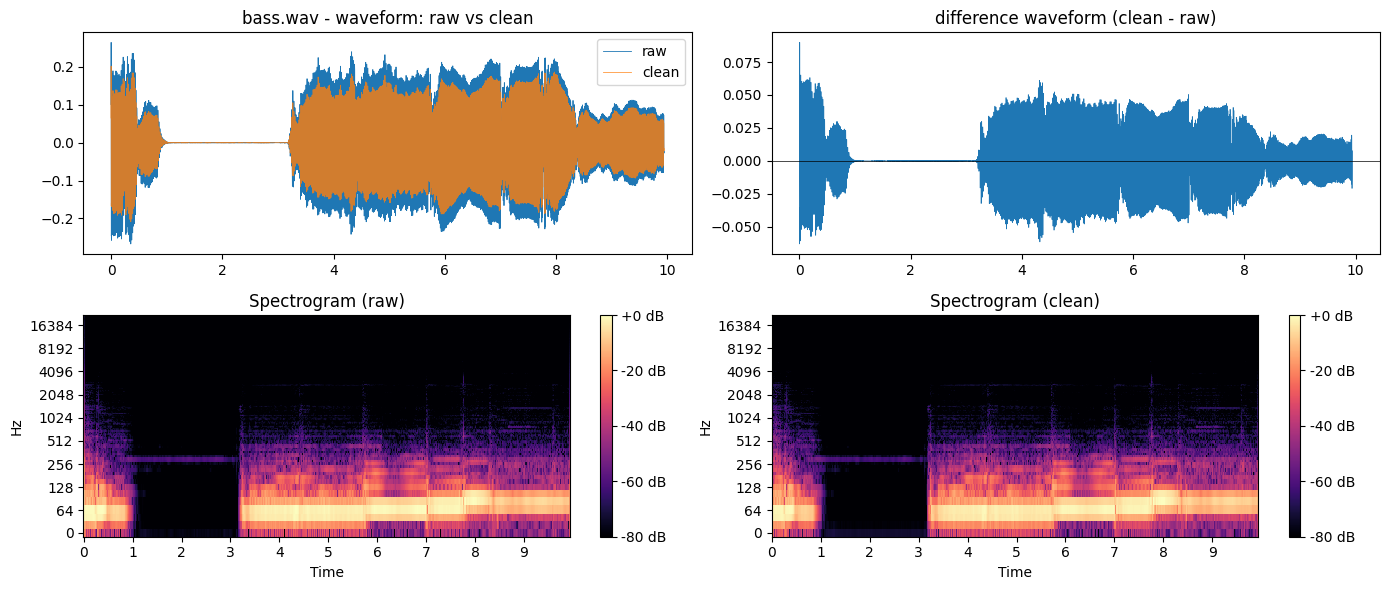

----------------------------------------------------------------------------------------------------------------------------------------------------------------




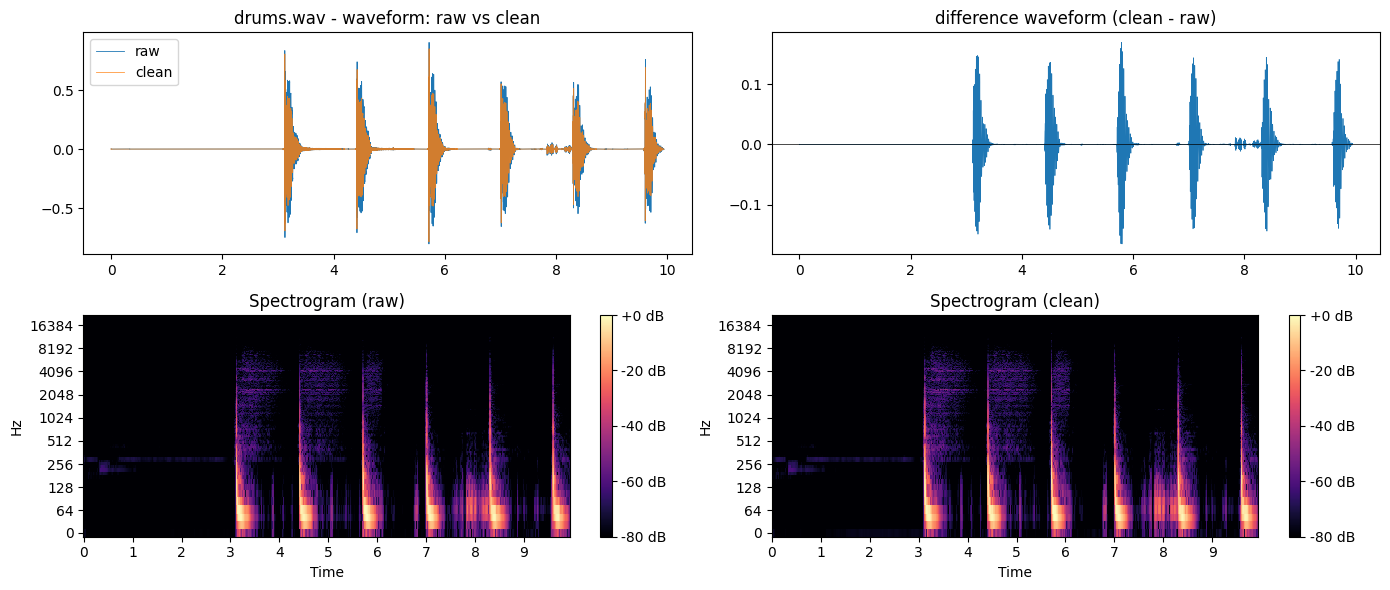

----------------------------------------------------------------------------------------------------------------------------------------------------------------




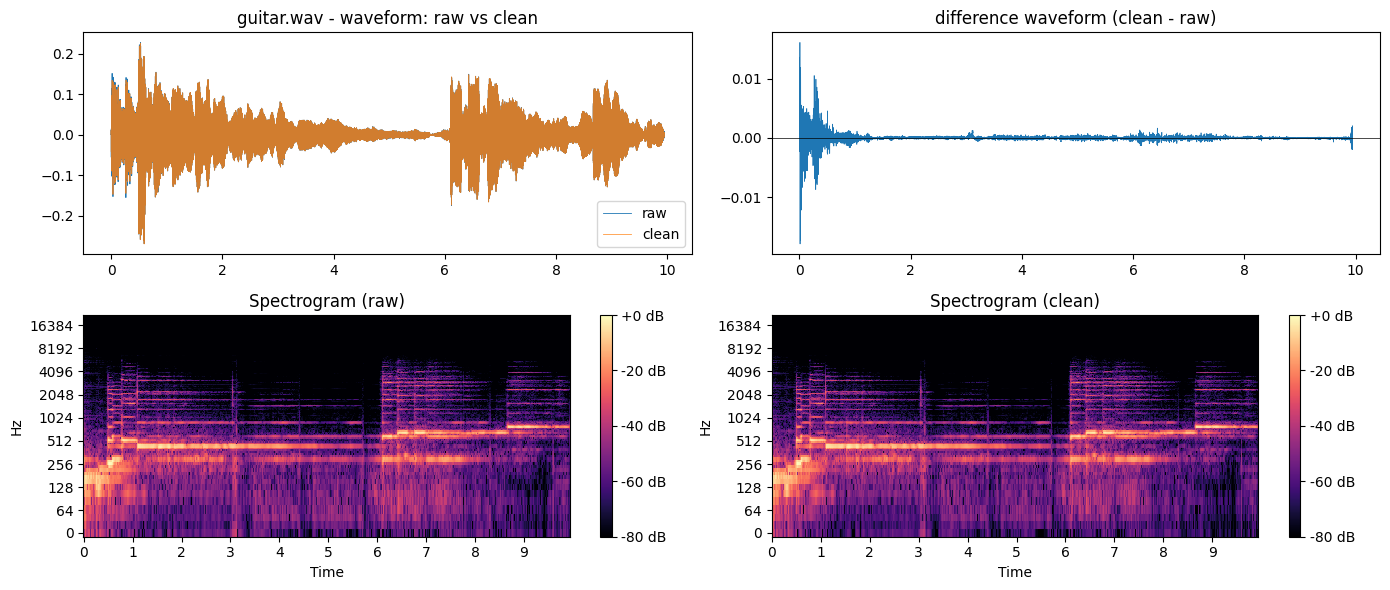

----------------------------------------------------------------------------------------------------------------------------------------------------------------




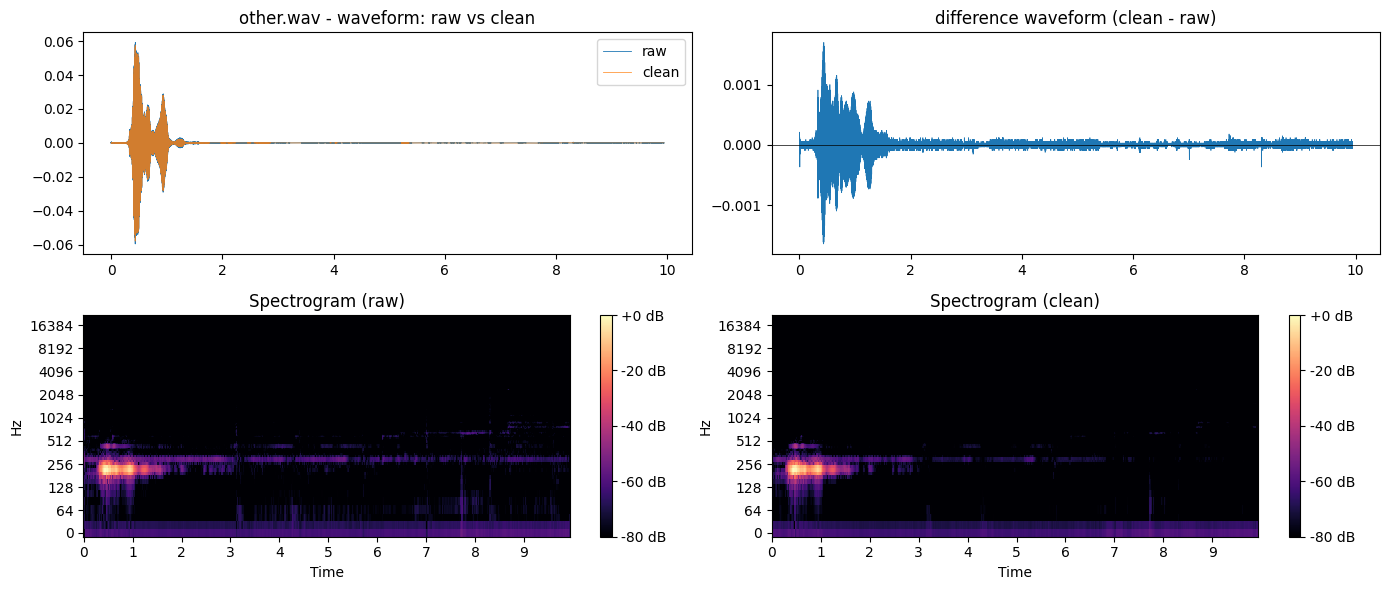

----------------------------------------------------------------------------------------------------------------------------------------------------------------




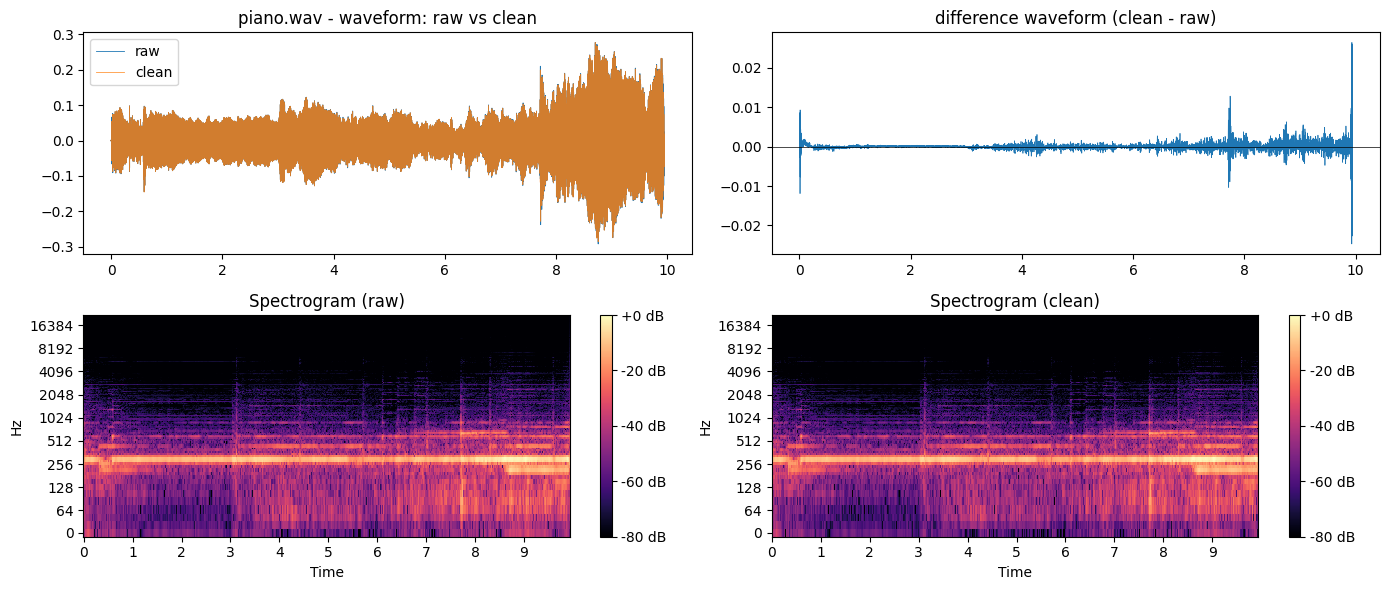

----------------------------------------------------------------------------------------------------------------------------------------------------------------




In [ ]:
sample = "sample_3"   # Select the audio you want to see graphs for
raw_dir = f"data/stems/original/{sample}"
clean_dir = f"data/stems/denoised/{sample}"

files = sorted([f for f in os.listdir(clean_dir)])

for fname in files:

    raw_path = os.path.join(raw_dir, fname)
    clean_path = os.path.join(clean_dir, fname)

    raw, raw_sr = librosa.load(raw_path, sr = None)
    clean, clean_sr = librosa.load(clean_path, sr = None)

    L = min(len(raw), len(clean))
    raw = raw[:L]
    clean = clean[:L]

    noise = clean - raw

    fig, axs = plt.subplots(2,2, figsize=(14,6))
    axs = axs.flatten()
    t = np.arange(L) / raw_sr

    axs[0].set_title(f"{fname} - waveform: raw vs clean")
    axs[0].plot(t, raw, linewidth=0.6)
    axs[0].plot(t, clean, linewidth=0.6, alpha=0.8)
    axs[0].legend(["raw","clean"])

    axs[1].set_title("difference waveform (clean - raw)")
    axs[1].plot(t, noise, linewidth=0.5)
    axs[1].axhline(0, color='k', linewidth=0.5)

    D1 = librosa.amplitude_to_db(np.abs(librosa.stft(raw, n_fft=2048)), ref=np.max)
    img = librosa.display.specshow(D1, sr=clean_sr, x_axis='time', y_axis='log', ax=axs[2])
    axs[2].set_title("Spectrogram (raw)")
    fig.colorbar(img, ax=axs[2], format="%+2.f dB")

    D2 = librosa.amplitude_to_db(np.abs(librosa.stft(clean, n_fft=2048)), ref=np.max)
    img = librosa.display.specshow(D2, sr=clean_sr, x_axis='time', y_axis='log', ax=axs[3])
    axs[3].set_title("Spectrogram (clean)")
    fig.colorbar(img, ax=axs[3], format="%+2.f dB")

    plt.tight_layout()
    plt.show()

    print('-' * 160)
    print('\n')


# DNSMOS
This part of the notebook is dedicated to the evaluation of clean stems. To do this, we'll use [DNSMOS](https://github.com/microsoft/DNS-Challenge/tree/master/DNSMOS) (Deep Noise Suppression Mean Opinion Score), a no-reference audio quality metric developed by Microsoft, based on deep learning models trained on thousands of human evaluations.
It provides three main scores—SIG (signal quality), BAK (background noise quality), and OVRL (overall quality)—on a scale of 1.0 to 5.0, where higher scores indicate clearer, cleaner, and more enjoyable audio.
It's particularly useful for evaluating the improvement of model-generated audio (e.g., MusicGen) without the need for a "perfect" reference.

In [ ]:
###### INSTALLING DNSMOS ######
%cd /content
!rm -rf DNS-Challenge
!git clone https://github.com/microsoft/DNS-Challenge.git

/content
Cloning into 'DNS-Challenge'...
remote: Enumerating objects: 1284985, done.
remote: Counting objects: 100% (186/186), done.
remote: Compressing objects: 100% (63/63), done.
remote: Total 1284985 (delta 145), reused 123 (delta 123), pack-reused 1284799 (from 2)
Receiving objects: 100% (1284985/1284985), 275.03 MiB | 15.76 MiB/s, done.
Resolving deltas: 100% (677/677), done.


In [ ]:
%cd /content/DNS-Challenge/DNSMOS/DNSMOS
!pip install onnxruntime librosa numpy

/content/DNS-Challenge/DNSMOS/DNSMOS
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 104.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 6.8 MB/s eta 0:00:00


In [ ]:
###### DNSMOS CLASS ######

import onnxruntime as ort #import the onnxruntime library which is used to run machine learning models saved in .onnx format — such as those used by DNSMOS.

MODEL_PATH = "/content/DNS-Challenge/DNSMOS/DNSMOS/sig_bak_ovr.onnx" # This model estimates SIG (Signal), BAK (Background), and OVRL (Overall) — three quality scores.

TARGET_LENGTH = 144160  # Defines how many samples the model's input audio should have.
                        # Since the model was trained on blocks of 144,160 samples at 16 kHz, each audio MUST be exactly this long.

class DNSMOS_New:
    def __init__(self, model_path):
        self.session = ort.InferenceSession(model_path) # Loads the machine learning model from the .onnx file and prepares it for inference (i.e., making predictions).

    def compute_dnsmos(self, audio_path):
        '''
        Args: file audio path
        Returns: quality scores
        '''
        audio, sr = librosa.load(audio_path, sr=16000, mono=True)

        if len(audio) < TARGET_LENGTH:                                              # Checks whether the audio is shorter or longer than TARGET_LENGTH (144160):
            audio = np.pad(audio, (0, TARGET_LENGTH - len(audio)), mode='constant') # If shorter, append zeros to the end (np.pad) to reach the required length.
        else:
            audio = audio[:TARGET_LENGTH]                                           # If longer, trim the audio to the first 144160 samples.

        input_data = np.expand_dims(audio.astype(np.float32), axis=0) # Transform the 1D array ([144160]) into a 2D array ([1, 144160]) because the
                                                                      # model expects a batch of inputs — even if you only pass one.

        input_name = self.session.get_inputs()[0].name    # This is used to correctly pass data to the template in the next row.

        output_names = [o.name for o in self.session.get_outputs()]  # It asks the model what outputs it produces.
                                                                     # In this case, the model returns an array with 3 values: [SIG, BAK, OVRL]

        outputs = self.session.run(output_names, {input_name: input_data})  # Run the model! Pass input_data and get the scores back.

        sig, bak, ovr = outputs[0][0]  # These are the scores that interest us

        return {
            "SIG": float(sig),
            "BAK": float(bak),
            "OVRL": float(ovr)
        }

dnsmos = DNSMOS_New(MODEL_PATH)

def dnsmos_scores(filepath, name="Audio"):
    '''
    Args: audio filepath

    -> Prints the results legibly

    Returns: the OVRL score (useful for comparisons)
    '''

    print(f"📈 Analyzing {name} stem...")

    scores = dnsmos.compute_dnsmos(filepath)

    ovrl = scores['OVRL']
    sig = scores['SIG']
    bak = scores['BAK']

    print(f"   OVRL (Overall): {ovrl:.4f}/5")
    print(f"   SIG (Signal): {sig:.4f}/5")
    print(f"   BAK (Backround): {bak:.4f}/5\n")

    return ovrl, sig, bak

In [ ]:
###### EVALUATION ######

sample = "sample_3"  # choose a sample to evaluate

folder_orig = os.path.join(PROJECT_PATH, f"data/stems/original/{sample}")
folder_impr = os.path.join(PROJECT_PATH, f"data/stems/denoised/{sample}")

stems = sorted(os.listdir(folder_impr))

improved = 0

for stem in stems:

    path_orig = os.path.join(folder_orig, stem)
    path_impr = os.path.join(folder_impr, stem)

    print("\n" + "="*50)
    print(" "*17 + f"stem: {stem}")
    print("="*50)

    ovrl_orig, sig_orig, bak_orig = dnsmos_scores(path_orig, "Original")
    ovrl_impr, sig_impr, bak_impr = dnsmos_scores(path_impr, "Denoised")

    delta_ovrl, delta_sig, delta_bak = (ovrl_impr - ovrl_orig), (sig_impr - sig_orig), (bak_impr - bak_orig)

    print("\n------📈 FINAL RESULTS 📈------")
    if delta_sig >= 0:
        print(f"SIG: +{delta_sig:.4f} -> useful signal preserved or improved✅")
    else:
        print(f"SIG: {delta_sig:.4f} -> the denoiser removed useful signal❌")

    if delta_bak > 0:
        print(f"BAK: +{delta_bak:.4f} -> noise and artifacts are reduced✅")
    else:
        print(f"BAK: {delta_bak:.4f} -> noise was not removed or artifacts were added❌")

    if delta_ovrl > 0:
        print(f"OVRL: +{delta_ovrl:.4f} -> the overall quality is IMPROVED✅")
        improved += 1
    else:
        print(f"OVRL: {delta_ovrl:.4f} -> the overall quality has DETERIORATED or remained UNCHANGED❌")


print('\n------------------------------------------------------------------------------------------------')
print(f"\n-> {improved} out of {len(stems)} improved stems")


                 stem: bass.wav
📈 Analyzing Original stem...
   OVRL (Overall): 2.9710/5
   SIG (Signal): 3.2829/5
   BAK (Backround): 4.0833/5

📈 Analyzing Denoised stem...
   OVRL (Overall): 3.0686/5
   SIG (Signal): 3.4234/5
   BAK (Backround): 4.1844/5


------📈 FINAL RESULTS 📈------
SIG: +0.1406 -> useful signal preserved or improved✅
BAK: +0.1011 -> noise and artifacts are reduced✅
OVRL: +0.0976 -> the overall quality is IMPROVED✅

                 stem: drums.wav
📈 Analyzing Original stem...
   OVRL (Overall): 2.0793/5
   SIG (Signal): 2.1591/5
   BAK (Backround): 3.8986/5

📈 Analyzing Denoised stem...
   OVRL (Overall): 2.1180/5
   SIG (Signal): 2.2660/5
   BAK (Backround): 3.7146/5


------📈 FINAL RESULTS 📈------
SIG: +0.1069 -> useful signal preserved or improved✅
BAK: -0.1840 -> noise was not removed or artifacts were added❌
OVRL: +0.0387 -> the overall quality is IMPROVED✅

                 stem: guitar.wav
📈 Analyzing Original stem...
   OVRL (Overall): 0.9348/5
   SIG (S